In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "base")))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, random
from functools import partial

jax.config.update("jax_enable_x64", True)

from tools import (
    I, X, Z,
    bracket, antibracket,
    channel_pack,
    run_trajectories_ito,
    run_trajectories_ito_nomonitor
)

In [2]:
@partial(jit, static_argnames=("n_steps",))
def run(rho0, key, n_steps, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt):
    return run_trajectories_ito_nomonitor(
        rho0, key, n_steps,
        pack_error, pack_ec,
        gamma_error, gamma_ec,
        Omega1, Omega2, dt,
    )

# SB-DB feedback with Luispe's operators (Itô)

In [5]:
# =============================================================================
# FEEDBACK-SPECIFIC: choose dΩ via Omega1 / Omega2 (SBDB example)
# =============================================================================

def build_omega_luispe(PQ, R, A, gammaEC):
    """
    Compute Omega1 and Omega2 in Luispe's feedback scheme.

    Omega2 = i [PQ, R]/2
    Omega1 = -gammaEC/2 * antibracket(A, Omega2)

    Parameters
    ----------
    PQ : array_like (N, N)             # Projector
    R  : array_like (n_ec, N, N)       # e.g., X1, X2, X3
    A  : array_like (n_ec, N, N)       # C4, C5, C6
    gammaEC : array_like (n_ec,)       # feedback rates

    Returns
    -------
    Omega1, Omega2 : each (n_ec, N, N)
    """
    n_ec = R.shape[0]
    PQ_rep = jnp.broadcast_to(PQ, (n_ec, PQ.shape[-2], PQ.shape[-1]))
    # [PQ, R]
    Omega2 = 1j * bracket(PQ_rep, R) / 2.0

    # Fix: gammaEC has shape (n_ec,), antibracket(A, Omega2) has (n_ec, N, N)
    # Need to reshape gammaEC so it broadcasts correctly
    Omega1 = -gammaEC[:, None, None] / 2.0 * antibracket(A, Omega2)

    return Omega1, Omega2

def J_corr(Rop, gammaC, lam):
    return gammaC * (P_C @ Rop + lam * Rop @ P_C @ Rop)

In [6]:
# =============================================================================
# OPERATORS / SETUP
# =============================================================================

n = 3
N = 2**n

T = 10.0
L = 1000
dt = T / L
n_traj = 50

gamma_error = 1e-3 * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = 1 * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)

e000 = jnp.zeros((N), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

C_error = jnp.stack([X1, X2, X3], axis=0)

lamb = 1.

C4 = 0.5 * antibracket(PQ, X1) + lamb * X1 @ PQ @ X1
C5 = 0.5 * antibracket(PQ, X2) + lamb * X2 @ PQ @ X2
C6 = 0.5 * antibracket(PQ, X3) + lamb * X3 @ PQ @ X3
C_ec = jnp.stack([C4, C5, C6], axis=0)

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)

# Omega1, Omega2 = build_omega_sbdb(
#     pack_ec["A"], pack_ec["B"], PQ, gamma_ec
# )

Omega1, Omega2 = build_omega_luispe(PQ, C_error, C_ec, gamma_ec)

# Omega1 = jnp.zeros_like(pack_ec["A"])
# Omega2 = jnp.zeros_like(pack_ec["A"])

q = e000
Q = q[:, None] @ jnp.conj(q)[None, :]

var = 0e-2  # example variance, adjust as needed
noise = jax.random.normal(random.PRNGKey(42), q.shape, dtype=q.dtype) * jnp.sqrt(var)
psi0 = q + noise
psi0 = psi0 / jnp.linalg.norm(psi0)
P0 = psi0[:, None] * jnp.conj(psi0)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))


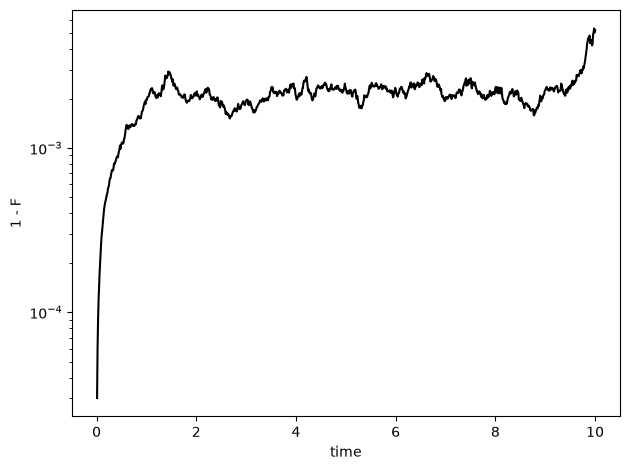

In [7]:
key = random.PRNGKey(0)
rho_all = run(rho0, key, L, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt)
rho_all.block_until_ready()

F_all = jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ))

times = dt * jnp.arange(1, L + 1)
mean_F = jnp.mean(F_all, axis=1)

plt.figure(2)
plt.semilogy(times, 1.0 - jnp.abs(mean_F), "k")
plt.xlabel("time")
plt.ylabel("1 - F")
plt.tight_layout()
plt.show()


|██████████| 100.0% ◆ elapsed 3.46ms ◆ remaining 0.00ms


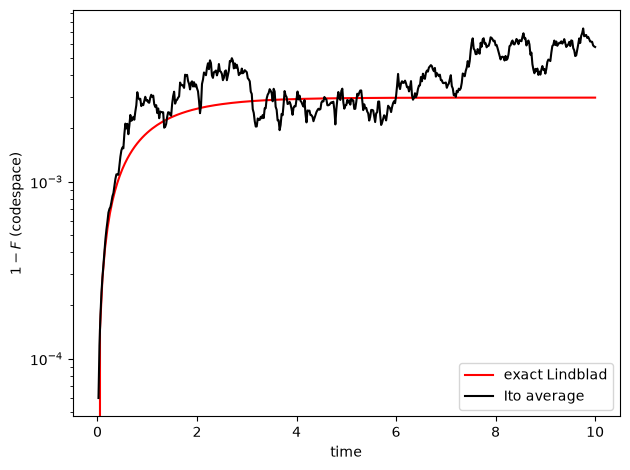

In [5]:
# Exact Lindblad vs Ito stochastic average — same params, expanded jumps {I, X1, X2, X3}
import dynamiqs as dq

n = 3
N = 2**n
T = 10.0
L = 500
dt = T / L
n_traj = 1000
lamb = 1.0
gamma_E = 1e-3
gamma_C = 1.0

gamma_error = gamma_E * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = gamma_C * jnp.array([1.0, 1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)
Id3 = jnp.eye(N, dtype=jnp.complex128)

e000 = jnp.zeros((N,), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N,), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

R = jnp.stack([Id3, X1, X2, X3], axis=0)
PQ_rep = jnp.broadcast_to(PQ, (R.shape[0], N, N))
C_error = jnp.stack([X1, X2, X3], axis=0)
C_ec = 0.5 * antibracket(PQ_rep, R) + lamb * jnp.matmul(R, jnp.matmul(PQ_rep, R))

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)
Omega1, Omega2 = build_omega_luispe(PQ, R, C_ec, gamma_ec)

P0 = e000[:, None] * jnp.conj(e000)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))

key = random.PRNGKey(0)
rho_all = run(rho0, key, L, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt)
rho_all.block_until_ready()
F_stoch = jnp.mean(jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ)), axis=1)
times = dt * jnp.arange(1, L + 1)

# Unconditional Lindblad: L^E = √γ_E X_i and J_s = √γ_C (P_C R + λ R P_C R)
X1_dq = dq.tensor(dq.sigmax(), dq.eye(2), dq.eye(2))
X2_dq = dq.tensor(dq.eye(2), dq.sigmax(), dq.eye(2))
X3_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.sigmax())
Id_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.eye(2))
ket000 = dq.tensor(dq.basis(2, 0), dq.basis(2, 0), dq.basis(2, 0))
ket111 = dq.tensor(dq.basis(2, 1), dq.basis(2, 1), dq.basis(2, 1))
P_C = ket000.proj() + ket111.proj()


jump_ops = [
    jnp.sqrt(gamma_E) * X1_dq,
    jnp.sqrt(gamma_E) * X2_dq,
    jnp.sqrt(gamma_E) * X3_dq,
    J_corr(Id_dq, gamma_C, lamb),
    J_corr(X1_dq, gamma_C, lamb),
    J_corr(X2_dq, gamma_C, lamb),
    J_corr(X3_dq, gamma_C, lamb),
]
tsave = jnp.linspace(0.0, T, 201)
result = dq.mesolve(0 * Id_dq, jump_ops, ket000, tsave, exp_ops=[P_C])
F_exact = jnp.real(result.expects[0])

plt.figure()
plt.semilogy(tsave, 1.0 - jnp.abs(F_exact), "r", label="exact Lindblad")
plt.semilogy(times, 1.0 - jnp.abs(F_stoch), "k", label="Ito average")
plt.xlabel("time")
plt.ylabel(r"$1-F$ (codespace)")
plt.legend()
plt.tight_layout()
plt.show()


<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
/var/folders/kg/tz6r0qm90td22k24mlsgk9sw0000gn/T/ipykernel_60121/4128903168.py:29: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Lindblad ($1-F$) for different $\lambda$")
|██████████| 100.0% ◆ elapsed 4.01ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 2.22ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 3.25ms ◆ remaining 0.00ms


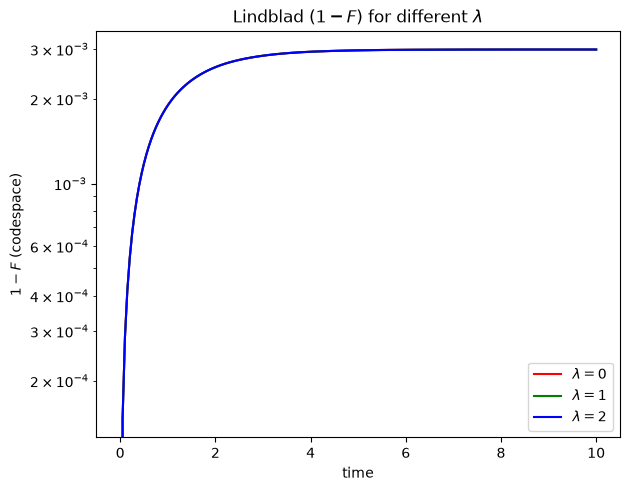

In [6]:
# Plot Lindblad dynamics for 3 different lambda values: 0, 1, 2

lambda_list = [0.0, 1.0, 2.0]
colors = ['r', 'g', 'b']
labels = [r'$\lambda=0$', r'$\lambda=1$', r'$\lambda=2$']
F_exact_all = []

plt.figure()
for idx, lamb_val in enumerate(lambda_list):
    # Rebuild the jump operators for each lambda
    jump_ops = [
        jnp.sqrt(gamma_E) * X1_dq,
        jnp.sqrt(gamma_E) * X2_dq,
        jnp.sqrt(gamma_E) * X3_dq,
        J_corr(Id_dq, gamma_C, lamb_val),
        J_corr(X1_dq, gamma_C, lamb_val),
        J_corr(X2_dq, gamma_C, lamb_val),
        J_corr(X3_dq, gamma_C, lamb_val),
    ]
    result = dq.mesolve(0 * Id_dq, jump_ops, ket000, tsave, exp_ops=[P_C])
    F_exact = jnp.real(result.expects[0])
    F_exact_all.append(F_exact)
    plt.semilogy(tsave, 1.0 - jnp.abs(F_exact), colors[idx], label=labels[idx])

plt.xlabel("time")
plt.ylabel(r"$1-F$ (codespace)")
plt.legend()
plt.tight_layout()
plt.title("Lindblad ($1-F$) for different $\lambda$")
plt.show()

# Interleaved digital correction

Analog Luispe vs the same noise with a Pauli kick from the **photocurrents only**.

The EWMA AND-rule (high Pauli \(m_s\), low \(m_I\), gap, cooldown) does **not** fire when it should: analog keeps \(m_I\) high, so a typical shot (traj 0) has 0 kicks. Raising \(\gamma_E\) still barely beats analog, because the four conditions almost never hold together on a real, unique coset.

**This cell** replaces that with a 4-coset filter on \(dy\). Hypotheses \(\{I,X_1,X_2,X_3\}\) have means
\(\langle A\rangle_I=(1+\lambda,0,0,0)\) and \(\langle A\rangle_{X_s}=\lambda\,e_s\).
The prior leaks at \(\gamma_E\) and recovers at \(\gamma_C\); Bayes updates \(\pi\) from \(dy\).
Apply \(R_s\) when \(\pi_s \ge p_\mathrm{kick}\), \(\pi_s>\pi_I\), and \(\pi_s\) beats the other Paulis by `gap_dig`.

At \(\gamma_E=0\) this does not false-kick. Re-run after imports / `build_omega_luispe`.


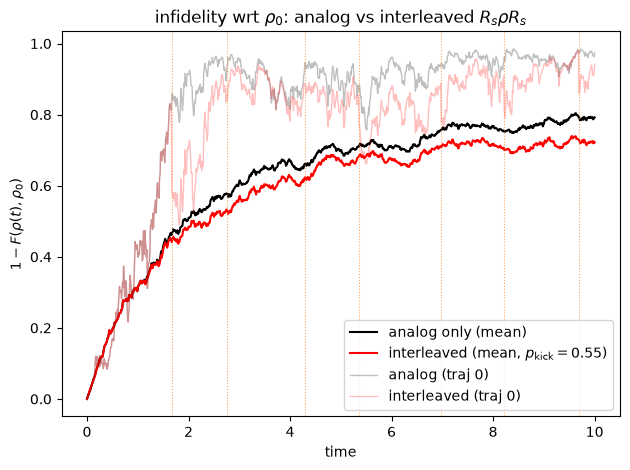

kicks / traj = [7, 5, 0, 3, 6, 2, 4, 6, 6, 4, 2, 5, 2, 3, 2, 4, 2, 0, 5, 3, 2, 3, 1, 2, 3, 2, 3, 3, 3, 4, 3, 5, 5, 4, 1, 5, 5, 4, 3, 3, 1, 4, 2, 0, 4, 8, 4, 1, 1, 3]
digital kicks on traj 0 = 7 at t = [1.67, 2.7600000000000002, 4.29, 5.36, 6.98, 8.22, 9.69]
mean infidelity analog / interleaved = 0.6232961510197113 0.5852294400370003


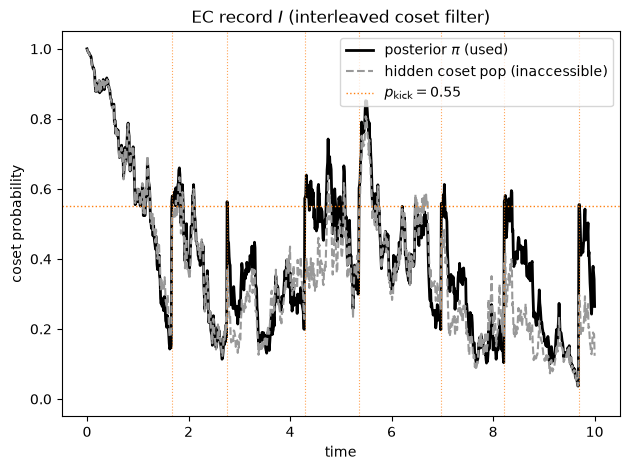

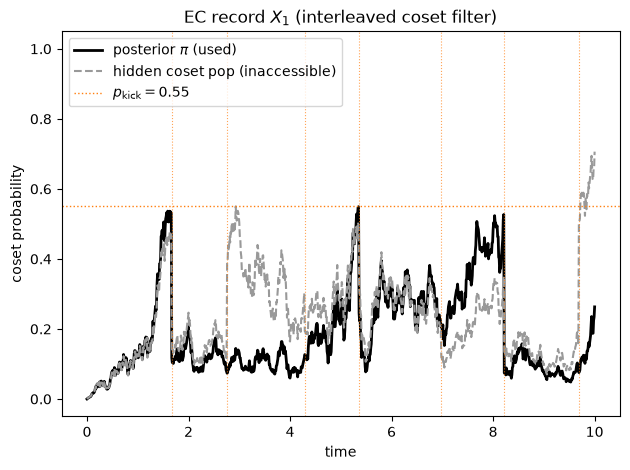

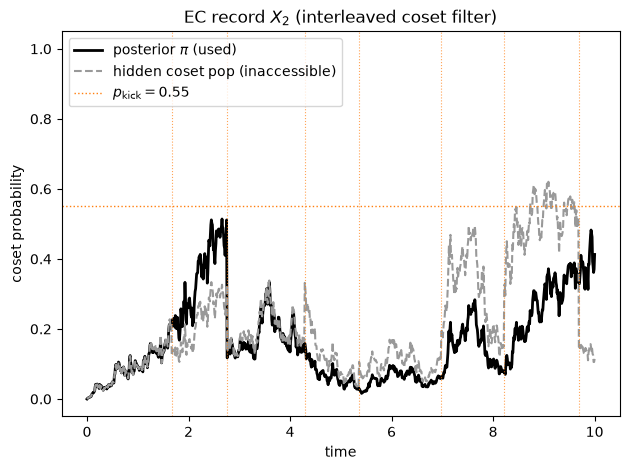

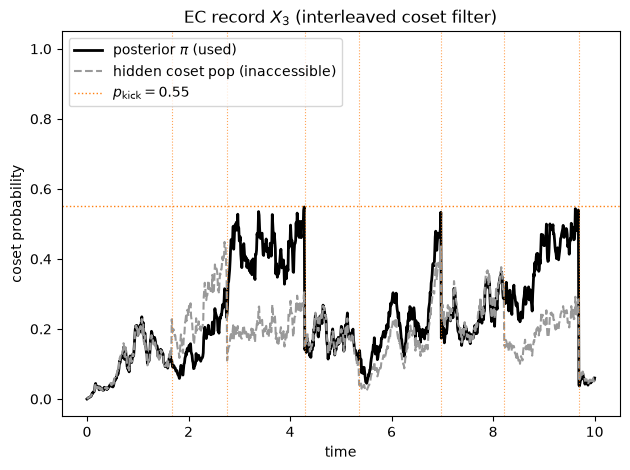

In [8]:
# Analog Luispe vs interleaved digital correction (coset filter on dy)
from jax import lax
from tools import measurement_increments, one_step_ito_nomonitor, project_psd

# Basis states for all 3-qubit computational states |ijk⟩, where i,j,k ∈ {0,1}
def basis_state(index, N):
    """Return N-dimensional standard basis vector with 1 at index."""
    return jnp.zeros((N,), dtype=jnp.complex128).at[index].set(1.0)

n = 3
N = 2**n
T = 10.0
L = 1000
dt = T / L
n_traj = 50
traj = 0

# Same analog point as the silent-EWMA run. Kick from a 4-coset filter on dy.
# p_kick=0.55: ~0 false alarms at gamma_E=0; traj 0 actually gates.
# gamma_E = 0.05
# lamb = 1.0
# gamma_C = 0.4
# p_kick = 0.55
# gap_dig = 0.10
# cd_time = 0.5
# analog_rate = gamma_C  # prior: analog pulls error cosets back toward I
gamma_E = 0.15
lamb = 1.0
gamma_C = 0.15
p_kick = 0.55
gap_dig = 0.10
cd_time = 0.5
analog_rate = gamma_C



gamma_error = gamma_E * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = gamma_C * jnp.array([1.0, 1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)
Id3 = jnp.eye(N, dtype=jnp.complex128)

e000 = basis_state(0b000, N)
e001 = basis_state(0b001, N)
e010 = basis_state(0b010, N)
e011 = basis_state(0b011, N)
e100 = basis_state(0b100, N)
e101 = basis_state(0b101, N)
e110 = basis_state(0b110, N)
e111 = basis_state(0b111, N)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

R = jnp.stack([Id3, X1, X2, X3], axis=0)
PQ_rep = jnp.broadcast_to(PQ, (R.shape[0], N, N))
C_error = jnp.stack([X1, X2, X3], axis=0)

C_ec = 0.5 * antibracket(PQ_rep, R) + lamb * jnp.matmul(R, jnp.matmul(PQ_rep, R))

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)
Omega1, Omega2 = build_omega_luispe(PQ, R, C_ec, gamma_ec)

rho0 = jnp.broadcast_to(e000[:, None] * jnp.conj(e000)[None, :][None, :, :], (n_traj, N, N))
R_pauli = R[1:]  # X1, X2, X3 — never kick on I
A_ops = pack_ec["A"]
P_coset = jnp.stack([R[k] @ PQ @ R[k] for k in range(4)], axis=0)
cd_steps = jnp.int32(jnp.maximum(cd_time / dt, 1.0))

# E[⟨A_c⟩ | hypothesis h]; h,c ∈ {I, X1, X2, X3}
mu_expect = jnp.zeros((4, 4), dtype=jnp.float64)
mu_expect = mu_expect.at[0, 0].set(1.0 + lamb)
mu_expect = mu_expect.at[1, 1].set(lamb)
mu_expect = mu_expect.at[2, 2].set(lamb)
mu_expect = mu_expect.at[3, 3].set(lamb)

pi0 = jnp.broadcast_to(
    jnp.array([1.0, 0.0, 0.0, 0.0], dtype=jnp.float64)[None, :],
    (n_traj, 4),
)
cd0 = jnp.zeros((n_traj,), dtype=jnp.int32)


def coset_prior_step(pi):
    """HMM prior: bit-flip leak I→X_s at γ_E, analog recovery X_s→I at analog_rate."""
    pi_I = pi[:, 0]
    pi_s = pi[:, 1:]
    leak = gamma_E * dt * pi_I[:, None]
    rec = analog_rate * dt * pi_s
    pi_I2 = pi_I * (1.0 - 3.0 * gamma_E * dt) + jnp.sum(rec, axis=-1)
    pi_s2 = pi_s * (1.0 - analog_rate * dt) + leak
    pi = jnp.concatenate([pi_I2[:, None], pi_s2], axis=-1)
    pi = jnp.maximum(pi, 1e-16)
    return pi / jnp.sum(pi, axis=-1, keepdims=True)


def bayes_from_dy(pi, dy):
    """π ← normalize(π L(dy|h)), dy_c ~ N(2 γ_c μ_{h,c} dt, γ_c dt)."""
    mean = 2.0 * gamma_ec[None, None, :] * mu_expect[None, :, :] * dt
    var = (gamma_ec * dt)[None, None, :]
    logL = -jnp.sum((dy[:, None, :] - mean) ** 2 / (2.0 * var), axis=-1)
    logL = logL - jnp.max(logL, axis=-1, keepdims=True)
    pi = pi * jnp.exp(logL)
    return pi / jnp.sum(pi, axis=-1, keepdims=True)


def digital_correct_from_posterior(rho, pi, cd, R_pauli, p_kick, gap, cd_steps):
    """Kick R_s from the record only: confident, unique Pauli posterior, cooldown."""
    pi_pauli = pi[:, 1:]
    best = jnp.max(pi_pauli, axis=-1)
    second = jnp.sort(pi_pauli, axis=-1)[:, -2]
    idx = jnp.argmax(pi_pauli, axis=-1)
    any_hit = (best >= p_kick) & (best >= second + gap) & (best > pi[:, 0]) & (cd <= 0)
    R_sel = R_pauli[idx]
    rho_corr = jnp.matmul(R_sel, jnp.matmul(rho, R_sel))
    rho = jnp.where(any_hit[:, None, None], project_psd(rho_corr), rho)
    traj_ix = jnp.arange(pi.shape[0])
    pi_I = pi[:, 0]
    pi_s = pi[traj_ix, 1 + idx]
    pi2 = pi.at[:, 0].set(jnp.where(any_hit, pi_s, pi_I))
    pi2 = pi2.at[traj_ix, 1 + idx].set(jnp.where(any_hit, pi_I, pi_s))
    cd = jnp.where(any_hit, cd_steps, jnp.maximum(cd - 1, 0))
    return rho, pi2, cd, any_hit


@partial(jit, static_argnames=("do_digital",))
def run_ito_with_dy_nomonitor(
    rho0, pi0, cd0, dw_ec, pack_error, pack_ec, R_pauli,
    gamma_error, gamma_ec, Omega1, Omega2, dt, p_kick, gap, cd_steps, do_digital,
):
    def body(state, dw_c):
        rho, pi, cd = state
        dy_c = measurement_increments(rho, pack_ec["A"], gamma_ec, dw_c, dt)
        rho = one_step_ito_nomonitor(
            rho, dw_c, pack_error, pack_ec,
            gamma_error, gamma_ec, Omega1, Omega2, dt,
        )
        pi = bayes_from_dy(coset_prior_step(pi), dy_c)
        if do_digital:
            rho, pi, cd, hit = digital_correct_from_posterior(
                rho, pi, cd, R_pauli, p_kick, gap, cd_steps
            )
        else:
            hit = jnp.zeros((rho.shape[0],), dtype=bool)
            cd = jnp.maximum(cd - 1, 0)
        return (rho, pi, cd), (rho, dy_c, pi, hit)

    _, (rho_all, dy_c_all, pi_all, hit_all) = lax.scan(body, (rho0, pi0, cd0), dw_ec)
    return rho0, rho_all, dy_c_all, pi_all, hit_all


key = random.PRNGKey(0)
dw_ec = jnp.sqrt(gamma_C * dt) * random.normal(
    key, (L, n_traj, gamma_ec.shape[0])
)
run_args = dict(
    rho0=rho0, pi0=pi0, cd0=cd0, dw_ec=dw_ec, pack_error=pack_error, pack_ec=pack_ec,
    R_pauli=R_pauli, gamma_error=gamma_error, gamma_ec=gamma_ec,
    Omega1=Omega1, Omega2=Omega2, dt=dt, p_kick=p_kick,
    gap=gap_dig, cd_steps=cd_steps,
)
rho0_off, rho_off, dy_off, pi_off, hit_off = run_ito_with_dy_nomonitor(**run_args, do_digital=False)
rho0_on, rho_on, dy_on, pi_on, hit_on = run_ito_with_dy_nomonitor(**run_args, do_digital=True)
rho_on.block_until_ready()

times = dt * jnp.arange(1, L + 1)
times_plot = jnp.concatenate([jnp.array([0.0]), times])


def fidelity_plot(rho0_run, rho_all):
    F0 = jnp.real(jnp.einsum("ij,ji", rho0_run[traj], rho0[traj]))
    F = jnp.real(jnp.einsum("sij,ji->s", rho_all[:, traj], rho0[traj]))
    return jnp.concatenate([jnp.array([F0]), F])


F_off = fidelity_plot(rho0_off, rho_off)
F_on = fidelity_plot(rho0_on, rho_on)
F_off_mean = jnp.mean(jnp.real(jnp.einsum("stij,ji->st", rho_off, rho0[0])), axis=1)
F_on_mean = jnp.mean(jnp.real(jnp.einsum("stij,ji->st", rho_on, rho0[0])), axis=1)
F_off_mean = jnp.concatenate([jnp.array([1.0]), F_off_mean])
F_on_mean = jnp.concatenate([jnp.array([1.0]), F_on_mean])

kick_t = times[jnp.where(hit_on[:, traj])[0]]

plt.figure()
plt.plot(times_plot, 1.0 - jnp.abs(F_off_mean), "k", label="analog only (mean)")
plt.plot(times_plot, 1.0 - jnp.abs(F_on_mean), "r", label=rf"interleaved (mean, $p_\mathrm{{kick}}={p_kick:g}$)")
plt.plot(times_plot, 1.0 - jnp.abs(F_off), "k", alpha=0.25, lw=1, label=rf"analog (traj {traj})")
plt.plot(times_plot, 1.0 - jnp.abs(F_on), "r", alpha=0.25, lw=1, label=rf"interleaved (traj {traj})")
for t in kick_t:
    plt.axvline(float(t), color="C1", ls=":", lw=0.8, alpha=0.7)
plt.xlabel("time")
plt.ylabel(r"$1-F(\rho(t),\rho_0)$")
plt.title(r"infidelity wrt $\rho_0$: analog vs interleaved $R_s\rho R_s$")
plt.legend()
plt.tight_layout()
plt.show()

# Posterior used for the kick. True coset pop is diagnostic only.
pop0 = jnp.real(jnp.einsum("cij,ji->c", P_coset, rho0_on[traj]))
pop = jnp.real(jnp.einsum("cij,sji->sc", P_coset, rho_on[:, traj]))
pop_plot = jnp.concatenate([pop0[None, :], pop], axis=0)
pi_plot = jnp.concatenate([pi0[traj][None, :], pi_on[:, traj]], axis=0)

kicks_per_traj = jnp.sum(hit_on, axis=0)
print("kicks / traj =", [int(x) for x in kicks_per_traj])
print(f"digital kicks on traj {traj} =", int(kicks_per_traj[traj]), "at t =", [float(t) for t in kick_t])
print(
    "mean infidelity analog / interleaved =",
    float(jnp.mean(1.0 - jnp.abs(F_off_mean[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_on_mean[1:]))),
)

ec_labels = [r"$I$", r"$X_1$", r"$X_2$", r"$X_3$"]

for i, lab in enumerate(ec_labels):
    plt.figure()
    plt.plot(times_plot, pi_plot[:, i], "k", lw=2, label=r"posterior $\pi$ (used)")
    plt.plot(times_plot, pop_plot[:, i], color="0.6", ls="--", lw=1.5,
             label=r"hidden coset pop (inaccessible)")
    plt.axhline(p_kick, color="C1", ls=":", lw=1, label=rf"$p_\mathrm{{kick}}={p_kick:g}$")
    for t in kick_t:
        plt.axvline(float(t), color="C1", ls=":", lw=0.8, alpha=0.7)
    plt.ylim(-0.05, 1.05)
    plt.xlabel("time")
    plt.ylabel(r"coset probability")
    plt.title(rf"EC record {lab} (interleaved coset filter)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Sarovar–Ahn 2004 vs interleaved Luispe

Same errors, time, and \(|000\rangle\) as the previous cell. The 2004 protocol ([quant-ph/0402017](https://arxiv.org/abs/quant-ph/0402017), PRA **69**, 052324) is **not** the 2002 Ahn SME estimator. It weakly measures the bit-flip **stabilizers** \(ZZI\) and \(IZZ\), low-pass filters the currents, and applies a **continuous** \(X\) Hamiltonian whose strength is set by the signs of the filtered signals.

**Filter** (Eq. 19, \(T\to\infty\) so the exponential is not truncated):

\[
R_i\leftarrow R_i-r R_i\,dt+\frac{r}{2\kappa}\,dQ_i,\qquad
dQ_i=2\kappa\langle M_i\rangle dt+\sqrt{\kappa}\,dW_i.
\]

Stationary \(R_i=\langle M_i\rangle\in\{\pm 1\}\). Feedback (Eqs. 22–29): if \(R_1<0,R_2>0\) drive \(X_1\) with \(G=R_1\); if \(R_1>0,R_2<0\) drive \(X_3\) with \(G=R_2\); if both negative drive \(X_2\) with \(G=R_1\); if both positive, no drive.

**Fairness / when Luispe+Bayes should win.** The first comparison gave Ahn a much stronger *actuator* than analog recovery: \(\lambda_\mathrm{fb}=3\) does a \(\pi\) pulse in time \(\approx 0.5\), while Luispe analog recovers on \(1/\gamma_C\). That is not a detector contest.

Matched resources: per-channel \(\kappa=\gamma_C\), and Ahn drive \(\lambda_\mathrm{fb}=(\pi/2)\gamma_C\) (a \(\pi\) pulse in time \(1/\gamma_C\)). Then the Luispe unraveling plus a Bayesian kick wins: analog already implements exact dissipative QEC, and \(\lambda\) in \(A_R\) sets the mean gap the filter uses. Ahn’s sign heuristic on a low-pass \(R_i\) is a worse estimator and, at \(\gamma_E=0\) with a strong drive, false-rotates.

The cell below plots the previous (overpowered) Ahn curve and the matched-actuator one, then an analog-dominated point (\(\gamma_C>\gamma_E\), larger Luispe \(\lambda\)) where the gap is obvious.


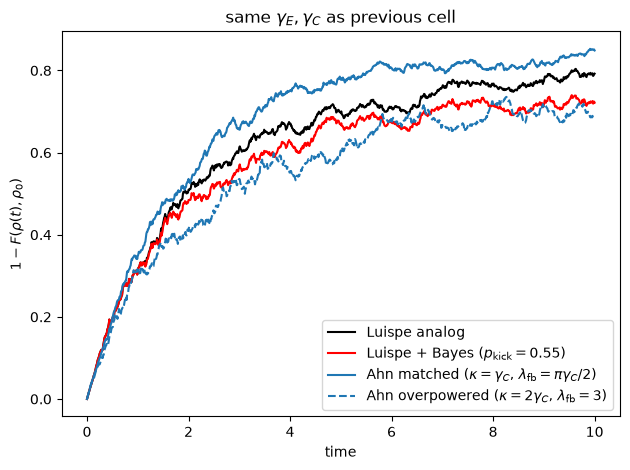

this point analog / inter / Ahn-matched / Ahn-strong = 0.6232961510197113 0.5852294400370003 0.6803081286979028 0.5527193709892299


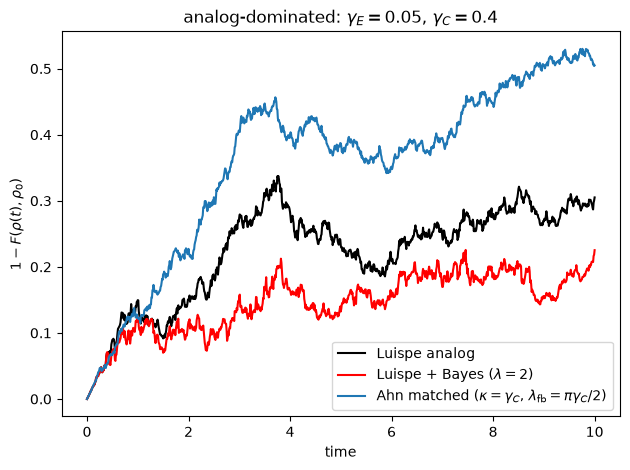

analog-dominated analog / inter / Ahn-matched = 0.22344827367654035 0.1463652438267424 0.3568999737441182


In [ ]:
# Sarovar–Ahn 2004 vs Luispe+Bayes (run after the interleaved cell)
# Overpowered Ahn: κ=2γ_C and λ_fb=3 (π-pulse in ~0.5). That is a stronger
# actuator than analog recovery ~γ_C — not a fair detector comparison.
# Matched Ahn: κ=γ_C, λ_fb=(π/2)γ_C (π-pulse in time 1/γ_C).
Z1 = jnp.kron(jnp.kron(Z, I), I)
Z2 = jnp.kron(jnp.kron(I, Z), I)
Z3 = jnp.kron(jnp.kron(I, I), Z)
pack_stab = channel_pack(jnp.stack([Z1 @ Z2, Z2 @ Z3], axis=0))
Omega_stab = jnp.zeros_like(pack_stab["A"])
R_ahn0 = jnp.ones((n_traj, 2), dtype=jnp.float64)
r_ahn = 1.0


def run_ahn_sarovar(rho0, dw_stab, kappa, lam_fb, r_filt, g_err):
    """SME: bit-flip errors + weak ZZI/IZZ + filtered-sign X Hamiltonians."""
    g_stab = kappa * jnp.ones(2, dtype=jnp.float64)
    scale = r_filt / (2.0 * kappa)

    def body(state, dw_c):
        rho, Rfilt = state
        dQ = measurement_increments(rho, pack_stab["A"], g_stab, dw_c, dt)
        rho = one_step_ito_nomonitor(
            rho, dw_c, pack_error, pack_stab,
            g_err, g_stab, Omega_stab, Omega_stab, dt,
        )
        Rfilt = Rfilt * (1.0 - r_filt * dt) + scale * dQ
        g1 = jnp.where((Rfilt[:, 0] < 0.0) & (Rfilt[:, 1] > 0.0), Rfilt[:, 0], 0.0)
        g2 = jnp.where((Rfilt[:, 0] < 0.0) & (Rfilt[:, 1] < 0.0), Rfilt[:, 0], 0.0)
        g3 = jnp.where((Rfilt[:, 0] > 0.0) & (Rfilt[:, 1] < 0.0), Rfilt[:, 1], 0.0)
        Hfb = lam_fb * (
            g1[:, None, None] * X1 + g2[:, None, None] * X2 + g3[:, None, None] * X3
        )
        rho = project_psd(rho - 1j * bracket(Hfb, rho) * dt)
        return (rho, Rfilt), rho

    _, rho_all = lax.scan(body, (rho0, R_ahn0), dw_stab)
    return rho_all


def inf_mean(rho_all, rho_ref):
    F = jnp.mean(jnp.real(jnp.einsum("stij,ji->st", rho_all, rho_ref[0])), axis=1)
    return jnp.concatenate([jnp.array([1.0]), F])


key_ahn = random.PRNGKey(1)
lam_matched = 0.5 * jnp.pi * gamma_C
kappa_match, kappa_strong = gamma_C, 2.0 * gamma_C
lam_strong = 3.0

dw_match = jnp.sqrt(kappa_match * dt) * random.normal(key_ahn, (L, n_traj, 2))
dw_strong = jnp.sqrt(kappa_strong * dt) * random.normal(random.PRNGKey(2), (L, n_traj, 2))
rho_ahn_m = run_ahn_sarovar(rho0, dw_match, kappa_match, lam_matched, r_ahn, gamma_error)
rho_ahn_s = run_ahn_sarovar(rho0, dw_strong, kappa_strong, lam_strong, r_ahn, gamma_error)
rho_ahn_s.block_until_ready()

F_ahn_m = inf_mean(rho_ahn_m, rho0)
F_ahn_s = inf_mean(rho_ahn_s, rho0)

plt.figure()
plt.plot(times_plot, 1.0 - jnp.abs(F_off_mean), "k", label="Luispe analog")
plt.plot(times_plot, 1.0 - jnp.abs(F_on_mean), "r", label=rf"Luispe + Bayes ($p_\mathrm{{kick}}={p_kick:g}$)")
plt.plot(times_plot, 1.0 - jnp.abs(F_ahn_m), "C0",
         label=rf"Ahn matched ($\kappa=\gamma_C$, $\lambda_\mathrm{{fb}}=\pi\gamma_C/2$)")
plt.plot(times_plot, 1.0 - jnp.abs(F_ahn_s), "C0", ls="--",
         label=rf"Ahn overpowered ($\kappa=2\gamma_C$, $\lambda_\mathrm{{fb}}={lam_strong:g}$)")
plt.xlabel("time")
plt.ylabel(r"$1-F(\rho(t),\rho_0)$")
plt.title(r"same $\gamma_E,\gamma_C$ as previous cell")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "this point analog / inter / Ahn-matched / Ahn-strong =",
    float(jnp.mean(1.0 - jnp.abs(F_off_mean[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_on_mean[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_ahn_m[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_ahn_s[1:]))),
)

# Analog-dominated + larger Luispe λ: dissipative QEC does the work; Bayes uses a
# bigger ⟨A⟩ gap. Ahn keeps a sign heuristic on two stabilizer currents.
gE_ad, gC_ad, lamb_ad = 0.05, 0.40, 2.0
g_err_ad = gE_ad * jnp.ones(3, dtype=jnp.float64)
g_ec_ad = gC_ad * jnp.ones(4, dtype=jnp.float64)
C_ec_ad = 0.5 * antibracket(PQ_rep, R) + lamb_ad * jnp.matmul(R, jnp.matmul(PQ_rep, R))
pack_ec_ad = channel_pack(C_ec_ad)
Om1_ad, Om2_ad = build_omega_luispe(PQ, R, C_ec_ad, g_ec_ad)
mu_ad = jnp.zeros((4, 4), dtype=jnp.float64)
mu_ad = mu_ad.at[0, 0].set(1.0 + lamb_ad)
mu_ad = mu_ad.at[1, 1].set(lamb_ad).at[2, 2].set(lamb_ad).at[3, 3].set(lamb_ad)
pi0_ad = jnp.broadcast_to(jnp.array([1.0, 0.0, 0.0, 0.0])[None, :], (n_traj, 4))
cd0_ad = jnp.zeros((n_traj,), dtype=jnp.int32)
cd_ad = jnp.int32(jnp.maximum(0.5 / dt, 1.0))
pk_ad, gap_ad = 0.55, 0.10


def prior_ad(pi):
    pi_I, pi_s = pi[:, 0], pi[:, 1:]
    leak = gE_ad * dt * pi_I[:, None]
    rec = gC_ad * dt * pi_s
    pi_I2 = pi_I * (1.0 - 3.0 * gE_ad * dt) + jnp.sum(rec, axis=-1)
    pi_s2 = pi_s * (1.0 - gC_ad * dt) + leak
    pi = jnp.concatenate([pi_I2[:, None], pi_s2], axis=-1)
    pi = jnp.maximum(pi, 1e-16)
    return pi / jnp.sum(pi, axis=-1, keepdims=True)


def bayes_ad(pi, dy):
    mean = 2.0 * g_ec_ad[None, None, :] * mu_ad[None, :, :] * dt
    var = (g_ec_ad * dt)[None, None, :]
    logL = -jnp.sum((dy[:, None, :] - mean) ** 2 / (2.0 * var), axis=-1)
    logL = logL - jnp.max(logL, axis=-1, keepdims=True)
    pi = pi * jnp.exp(logL)
    return pi / jnp.sum(pi, axis=-1, keepdims=True)


def kick_ad(rho, pi, cd):
    pp = pi[:, 1:]
    best, second = jnp.max(pp, axis=-1), jnp.sort(pp, axis=-1)[:, -2]
    idx = jnp.argmax(pp, axis=-1)
    hit = (best >= pk_ad) & (best >= second + gap_ad) & (best > pi[:, 0]) & (cd <= 0)
    Rsel = R_pauli[idx]
    rho = jnp.where(hit[:, None, None], project_psd(Rsel @ rho @ Rsel), rho)
    ix = jnp.arange(n_traj)
    pi_I, pi_s = pi[:, 0], pi[ix, 1 + idx]
    pi2 = pi.at[:, 0].set(jnp.where(hit, pi_s, pi_I))
    pi2 = pi2.at[ix, 1 + idx].set(jnp.where(hit, pi_I, pi_s))
    return rho, pi2, jnp.where(hit, cd_ad, jnp.maximum(cd - 1, 0))


@partial(jit, static_argnames=("do_digital",))
def run_luispe_ad(rho0, pi0, cd0, dw, do_digital):
    def body(state, dw_c):
        rho, pi, cd = state
        dy = measurement_increments(rho, pack_ec_ad["A"], g_ec_ad, dw_c, dt)
        rho = one_step_ito_nomonitor(
            rho, dw_c, pack_error, pack_ec_ad, g_err_ad, g_ec_ad, Om1_ad, Om2_ad, dt
        )
        pi = bayes_ad(prior_ad(pi), dy)
        if do_digital:
            rho, pi, cd = kick_ad(rho, pi, cd)
        return (rho, pi, cd), rho
    _, rho_all = lax.scan(body, (rho0, pi0, cd0), dw)
    return rho_all


dw_ad = jnp.sqrt(gC_ad * dt) * random.normal(random.PRNGKey(3), (L, n_traj, 4))
rho_ad_off = run_luispe_ad(rho0, pi0_ad, cd0_ad, dw_ad, False)
rho_ad_on = run_luispe_ad(rho0, pi0_ad, cd0_ad, dw_ad, True)
dw_ahn_ad = jnp.sqrt(gC_ad * dt) * random.normal(random.PRNGKey(4), (L, n_traj, 2))
rho_ad_ahn = run_ahn_sarovar(
    rho0, dw_ahn_ad, gC_ad, 0.5 * jnp.pi * gC_ad, r_ahn, g_err_ad
)
rho_ad_on.block_until_ready()

F_ad_off = inf_mean(rho_ad_off, rho0)
F_ad_on = inf_mean(rho_ad_on, rho0)
F_ad_ahn = inf_mean(rho_ad_ahn, rho0)

plt.figure()
plt.plot(times_plot, 1.0 - jnp.abs(F_ad_off), "k", label="Luispe analog")
plt.plot(times_plot, 1.0 - jnp.abs(F_ad_on), "r",
         label=rf"Luispe + Bayes ($\lambda={lamb_ad:g}$)")
plt.plot(times_plot, 1.0 - jnp.abs(F_ad_ahn), "C0",
         label=r"Ahn matched ($\kappa=\gamma_C$, $\lambda_\mathrm{fb}=\pi\gamma_C/2$)")
plt.xlabel("time")
plt.ylabel(r"$1-F(\rho(t),\rho_0)$")
plt.title(rf"analog-dominated: $\gamma_E={gE_ad:g}$, $\gamma_C={gC_ad:g}$")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "analog-dominated analog / inter / Ahn-matched =",
    float(jnp.mean(1.0 - jnp.abs(F_ad_off[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_ad_on[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_ad_ahn[1:]))),
)


# Exact Lindblad (\(\lambda=0\)) vs Sarovar–Ahn

Unconditional analog at \(\lambda=0\): SME jumps collapse to \(C_R=P_Q R\), so the master equation is bit-flip errors plus \(\sum_R \gamma_C\mathcal D[P_Q R]\). Compared only to the last cell’s Sarovar–Ahn protocol (matched and overpowered actuators), now averaged over many trajectories. Infidelity is \(1-F(\rho(t),|000\rangle\langle000|)\).


|██████████| 100.0% ◆ elapsed 3.64ms ◆ remaining 0.00ms


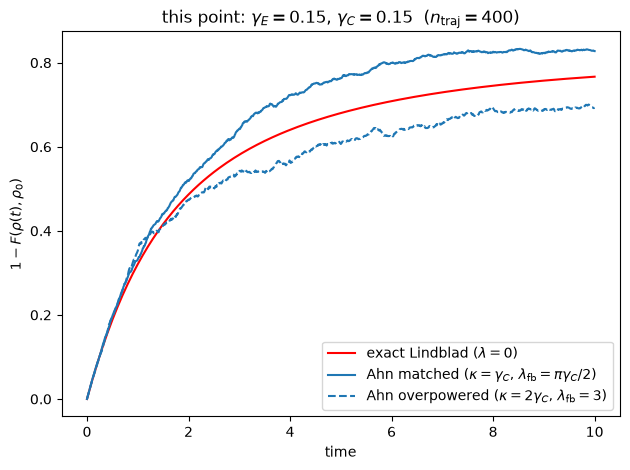

this point Lindblad λ=0 / Ahn-matched / Ahn-strong = 0.608827245160102 0.6711635298845832 0.5578682924603597


|██████████| 100.0% ◆ elapsed 2.06ms ◆ remaining 0.00ms


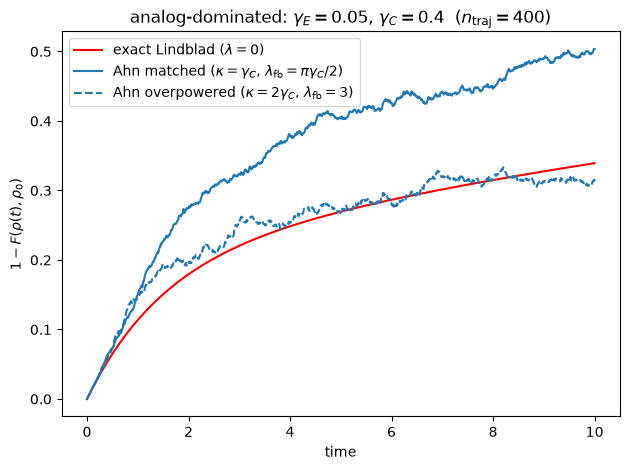

analog-dominated Lindblad λ=0 / Ahn-matched / Ahn-strong = 0.24516424713590415 0.36093689029934845 0.2532811763906331


In [13]:
# Exact Lindblad λ=0 vs Sarovar–Ahn ensemble (same rates as the last comparison)
import dynamiqs as dq
from jax import lax
from tools import measurement_increments, one_step_ito_nomonitor, project_psd

n = 3
N = 2**n
T = 10.0
L = 1000
dt = T / L
n_traj = 400
lam0 = 0.0
r_ahn = 1.0

# Last cell's two operating points
gE_pt, gC_pt = 0.15, 0.15
gE_ad, gC_ad = 0.05, 0.40

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)
Z1 = jnp.kron(jnp.kron(Z, I), I)
Z2 = jnp.kron(jnp.kron(I, Z), I)
Z3 = jnp.kron(jnp.kron(I, I), Z)
Id3 = jnp.eye(N, dtype=jnp.complex128)
e000 = jnp.zeros((N,), dtype=jnp.complex128).at[0].set(1.0)
P0 = e000[:, None] * jnp.conj(e000)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))
pack_error = channel_pack(jnp.stack([X1, X2, X3], axis=0))
pack_stab = channel_pack(jnp.stack([Z1 @ Z2, Z2 @ Z3], axis=0))
Omega_stab = jnp.zeros_like(pack_stab["A"])
R_ahn0 = jnp.ones((n_traj, 2), dtype=jnp.float64)

X1_dq = dq.tensor(dq.sigmax(), dq.eye(2), dq.eye(2))
X2_dq = dq.tensor(dq.eye(2), dq.sigmax(), dq.eye(2))
X3_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.sigmax())
Id_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.eye(2))
ket000 = dq.tensor(dq.basis(2, 0), dq.basis(2, 0), dq.basis(2, 0))
ket111 = dq.tensor(dq.basis(2, 1), dq.basis(2, 1), dq.basis(2, 1))
P_C = ket000.proj() + ket111.proj()
P000 = ket000.proj()


def L_corr(Rop, gammaC, lam):
    """SME jump at λ: L = √γ (P_Q R + λ R P_Q R). For λ=0 this is √γ P_Q R."""
    return jnp.sqrt(gammaC) * (P_C @ Rop + lam * Rop @ P_C @ Rop)


def exact_lindblad_F(gamma_E, gamma_C, lam):
    jump_ops = [
        jnp.sqrt(gamma_E) * X1_dq,
        jnp.sqrt(gamma_E) * X2_dq,
        jnp.sqrt(gamma_E) * X3_dq,
        L_corr(Id_dq, gamma_C, lam),
        L_corr(X1_dq, gamma_C, lam),
        L_corr(X2_dq, gamma_C, lam),
        L_corr(X3_dq, gamma_C, lam),
    ]
    tsave = jnp.linspace(0.0, T, 201)
    result = dq.mesolve(0 * Id_dq, jump_ops, ket000, tsave, exp_ops=[P000])
    return tsave, jnp.real(result.expects[0])


def run_ahn_sarovar(rho0, dw_stab, kappa, lam_fb, r_filt, g_err):
    g_stab = kappa * jnp.ones(2, dtype=jnp.float64)
    scale = r_filt / (2.0 * kappa)

    def body(state, dw_c):
        rho, Rfilt = state
        dQ = measurement_increments(rho, pack_stab["A"], g_stab, dw_c, dt)
        rho = one_step_ito_nomonitor(
            rho, dw_c, pack_error, pack_stab,
            g_err, g_stab, Omega_stab, Omega_stab, dt,
        )
        Rfilt = Rfilt * (1.0 - r_filt * dt) + scale * dQ
        g1 = jnp.where((Rfilt[:, 0] < 0.0) & (Rfilt[:, 1] > 0.0), Rfilt[:, 0], 0.0)
        g2 = jnp.where((Rfilt[:, 0] < 0.0) & (Rfilt[:, 1] < 0.0), Rfilt[:, 0], 0.0)
        g3 = jnp.where((Rfilt[:, 0] > 0.0) & (Rfilt[:, 1] < 0.0), Rfilt[:, 1], 0.0)
        Hfb = lam_fb * (
            g1[:, None, None] * X1 + g2[:, None, None] * X2 + g3[:, None, None] * X3
        )
        rho = project_psd(rho - 1j * bracket(Hfb, rho) * dt)
        return (rho, Rfilt), rho

    _, rho_all = lax.scan(body, (rho0, R_ahn0), dw_stab)
    return rho_all


def inf_mean(rho_all, rho_ref):
    F = jnp.mean(jnp.real(jnp.einsum("stij,ji->st", rho_all, rho_ref[0])), axis=1)
    return jnp.concatenate([jnp.array([1.0]), F])


def ahn_curves(gamma_E, gamma_C, key_m, key_s):
    g_err = gamma_E * jnp.ones(3, dtype=jnp.float64)
    lam_matched = 0.5 * jnp.pi * gamma_C
    kappa_match, kappa_strong = gamma_C, 2.0 * gamma_C
    lam_strong = 3.0
    dw_m = jnp.sqrt(kappa_match * dt) * random.normal(key_m, (L, n_traj, 2))
    dw_s = jnp.sqrt(kappa_strong * dt) * random.normal(key_s, (L, n_traj, 2))
    rho_m = run_ahn_sarovar(rho0, dw_m, kappa_match, lam_matched, r_ahn, g_err)
    rho_s = run_ahn_sarovar(rho0, dw_s, kappa_strong, lam_strong, r_ahn, g_err)
    rho_s.block_until_ready()
    return inf_mean(rho_m, rho0), inf_mean(rho_s, rho0)


times_plot = jnp.concatenate([jnp.array([0.0]), dt * jnp.arange(1, L + 1)])

ts_pt, F_lb_pt = exact_lindblad_F(gE_pt, gC_pt, lam0)
F_ahn_m_pt, F_ahn_s_pt = ahn_curves(gE_pt, gC_pt, random.PRNGKey(1), random.PRNGKey(2))

plt.figure()
plt.plot(ts_pt, 1.0 - jnp.abs(F_lb_pt), "r", label=r"exact Lindblad ($\lambda=0$)")
plt.plot(times_plot, 1.0 - jnp.abs(F_ahn_m_pt), "C0",
         label=r"Ahn matched ($\kappa=\gamma_C$, $\lambda_\mathrm{fb}=\pi\gamma_C/2$)")
plt.plot(times_plot, 1.0 - jnp.abs(F_ahn_s_pt), "C0", ls="--",
         label=r"Ahn overpowered ($\kappa=2\gamma_C$, $\lambda_\mathrm{fb}=3$)")
plt.xlabel("time")
plt.ylabel(r"$1-F(\rho(t),\rho_0)$")
plt.title(rf"this point: $\gamma_E={gE_pt:g}$, $\gamma_C={gC_pt:g}$  ($n_\mathrm{{traj}}={n_traj}$)")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "this point Lindblad λ=0 / Ahn-matched / Ahn-strong =",
    float(jnp.mean(1.0 - jnp.abs(F_lb_pt[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_ahn_m_pt[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_ahn_s_pt[1:]))),
)

ts_ad, F_lb_ad = exact_lindblad_F(gE_ad, gC_ad, lam0)
F_ahn_m_ad, F_ahn_s_ad = ahn_curves(gE_ad, gC_ad, random.PRNGKey(4), random.PRNGKey(5))

plt.figure()
plt.plot(ts_ad, 1.0 - jnp.abs(F_lb_ad), "r", label=r"exact Lindblad ($\lambda=0$)")
plt.plot(times_plot, 1.0 - jnp.abs(F_ahn_m_ad), "C0",
         label=r"Ahn matched ($\kappa=\gamma_C$, $\lambda_\mathrm{fb}=\pi\gamma_C/2$)")
plt.plot(times_plot, 1.0 - jnp.abs(F_ahn_s_ad), "C0", ls="--",
         label=r"Ahn overpowered ($\kappa=2\gamma_C$, $\lambda_\mathrm{fb}=3$)")
plt.xlabel("time")
plt.ylabel(r"$1-F(\rho(t),\rho_0)$")
plt.title(rf"analog-dominated: $\gamma_E={gE_ad:g}$, $\gamma_C={gC_ad:g}$  ($n_\mathrm{{traj}}={n_traj}$)")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "analog-dominated Lindblad λ=0 / Ahn-matched / Ahn-strong =",
    float(jnp.mean(1.0 - jnp.abs(F_lb_ad[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_ahn_m_ad[1:]))),
    float(jnp.mean(1.0 - jnp.abs(F_ahn_s_ad[1:]))),
)


# Variance

<>:84: SyntaxWarning: invalid escape sequence '\g'
<>:84: SyntaxWarning: invalid escape sequence '\g'
/var/folders/kg/tz6r0qm90td22k24mlsgk9sw0000gn/T/ipykernel_71441/2863847393.py:84: SyntaxWarning: invalid escape sequence '\g'
  ax.semilogy(tsave, inf_erroronly, "k", lw=2.1, label="exact Lindblad (only error, $\gamma_C=0$)", zorder=12)
|██████████| 100.0% ◆ elapsed 2.31ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 1.48ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 6.23ms ◆ remaining 0.00ms


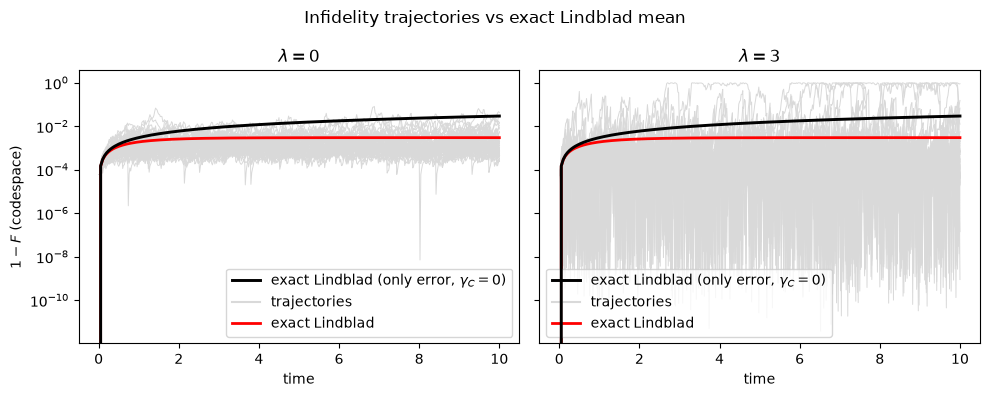

In [15]:
import dynamiqs as dq

n = 3
N = 2**n
T = 10.0
L = 500
dt = T / L
n_traj = 50
gamma_E = 1e-3
gamma_C = 1.0

gamma_error = gamma_E * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = gamma_C * jnp.array([1.0, 1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)
Id3 = jnp.eye(N, dtype=jnp.complex128)

e000 = jnp.zeros((N,), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N,), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

R = jnp.stack([Id3, X1, X2, X3], axis=0)
PQ_rep = jnp.broadcast_to(PQ, (R.shape[0], N, N))
C_error = jnp.stack([X1, X2, X3], axis=0)
pack_error = channel_pack(C_error)

P0 = e000[:, None] * jnp.conj(e000)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))
times = dt * jnp.arange(1, L + 1)

X1_dq = dq.tensor(dq.sigmax(), dq.eye(2), dq.eye(2))
X2_dq = dq.tensor(dq.eye(2), dq.sigmax(), dq.eye(2))
X3_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.sigmax())
Id_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.eye(2))
ket000 = dq.tensor(dq.basis(2, 0), dq.basis(2, 0), dq.basis(2, 0))
ket111 = dq.tensor(dq.basis(2, 1), dq.basis(2, 1), dq.basis(2, 1))
P_C = ket000.proj() + ket111.proj()
tsave = jnp.linspace(0.0, T, 201)

def J_corr_sqrt(Rop, gammaC, lam):
    return jnp.sqrt(gammaC) * (P_C @ Rop + lam * Rop @ P_C @ Rop)

def stochastic_infidelity(lamb, key):
    C_ec = 0.5 * antibracket(PQ_rep, R) + lamb * jnp.matmul(R, jnp.matmul(PQ_rep, R))
    pack_ec = channel_pack(C_ec)
    Omega1, Omega2 = build_omega_luispe(PQ, R, C_ec, gamma_ec)
    rho_all = run(
        rho0, key, L, pack_error, pack_ec,
        gamma_error, gamma_ec, Omega1, Omega2, dt,
    )
    rho_all.block_until_ready()
    F_traj = jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ))
    return 1.0 - jnp.abs(F_traj)

def exact_lindblad_infidelity(lamb, gamma_C_for_avg=None):
    # Optionally override gamma_C (to plot pure error, gamma_C=0)
    gC_use = gamma_C if gamma_C_for_avg is None else gamma_C_for_avg
    jump_ops = [
        jnp.sqrt(gamma_E) * X1_dq,
        jnp.sqrt(gamma_E) * X2_dq,
        jnp.sqrt(gamma_E) * X3_dq,
        J_corr_sqrt(Id_dq, gC_use, lamb),
        J_corr_sqrt(X1_dq, gC_use, lamb),
        J_corr_sqrt(X2_dq, gC_use, lamb),
        J_corr_sqrt(X3_dq, gC_use, lamb),
    ]
    result = dq.mesolve(0 * Id_dq, jump_ops, ket000, tsave, exp_ops=[P_C])
    F_exact = jnp.real(result.expects[0])
    return 1.0 - jnp.abs(F_exact)

# --- Prepare "only error" average dynamics (gamma_C=0, black curve) ---
inf_exact_erroronly = exact_lindblad_infidelity(0.0, gamma_C_for_avg=0.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, lamb, seed, inf_erroronly in zip(
    axes, (0.0, 3.0), (0, 1), (inf_exact_erroronly, inf_exact_erroronly)
):
    inf_traj = stochastic_infidelity(lamb, random.PRNGKey(seed))
    inf_exact = exact_lindblad_infidelity(lamb)

    # Plot only error average dynamics in black on top
    ax.semilogy(tsave, inf_erroronly, "k", lw=2.1, label="exact Lindblad (only error, $\gamma_C=0$)", zorder=12)

    ax.semilogy(times, inf_traj, color="0.85", lw=0.7)
    ax.semilogy([], [], color="0.85", lw=1.5, label="trajectories")
    ax.semilogy(tsave, inf_exact, "r", lw=2.0, label="exact Lindblad")
    ax.set_xlabel("time")
    ax.set_title(rf"$\lambda={lamb:g}$")
    ax.legend()

axes[0].set_ylabel(r"$1-F$ (codespace)")
fig.suptitle("Infidelity trajectories vs exact Lindblad mean")
fig.tight_layout()
plt.show()

<>:165: SyntaxWarning: invalid escape sequence '\g'
<>:165: SyntaxWarning: invalid escape sequence '\g'
/var/folders/kg/tz6r0qm90td22k24mlsgk9sw0000gn/T/ipykernel_71441/345685773.py:165: SyntaxWarning: invalid escape sequence '\g'
  ax.semilogy(tsave, inf_erroronly, "k", lw=2.1, label="exact Lindblad (only error, $\gamma_C=0$)", zorder=12)
|██████████| 100.0% ◆ elapsed 2.02ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 1.72ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 4.75ms ◆ remaining 0.00ms


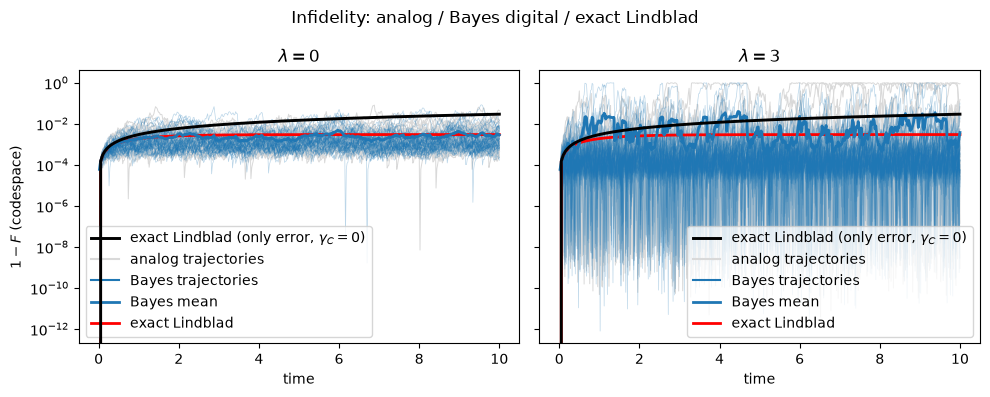

In [14]:
import dynamiqs as dq
from jax import lax
from tools import measurement_increments, one_step_ito_nomonitor, project_psd

n = 3
N = 2**n
T = 10.0
L = 500
dt = T / L
n_traj = 50
gamma_E = 1e-3
gamma_C = 1.0

gamma_error = gamma_E * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = gamma_C * jnp.array([1.0, 1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)
Id3 = jnp.eye(N, dtype=jnp.complex128)

e000 = jnp.zeros((N,), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N,), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

R = jnp.stack([Id3, X1, X2, X3], axis=0)
PQ_rep = jnp.broadcast_to(PQ, (R.shape[0], N, N))
C_error = jnp.stack([X1, X2, X3], axis=0)
pack_error = channel_pack(C_error)

P0 = e000[:, None] * jnp.conj(e000)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))
times = dt * jnp.arange(1, L + 1)

X1_dq = dq.tensor(dq.sigmax(), dq.eye(2), dq.eye(2))
X2_dq = dq.tensor(dq.eye(2), dq.sigmax(), dq.eye(2))
X3_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.sigmax())
Id_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.eye(2))
ket000 = dq.tensor(dq.basis(2, 0), dq.basis(2, 0), dq.basis(2, 0))
ket111 = dq.tensor(dq.basis(2, 1), dq.basis(2, 1), dq.basis(2, 1))
P_C = ket000.proj() + ket111.proj()
tsave = jnp.linspace(0.0, T, 201)

def J_corr_sqrt(Rop, gammaC, lam):
    return jnp.sqrt(gammaC) * (P_C @ Rop + lam * Rop @ P_C @ Rop)

def stochastic_infidelity(lamb, key):
    C_ec = 0.5 * antibracket(PQ_rep, R) + lamb * jnp.matmul(R, jnp.matmul(PQ_rep, R))
    pack_ec = channel_pack(C_ec)
    Omega1, Omega2 = build_omega_luispe(PQ, R, C_ec, gamma_ec)
    rho_all = run(
        rho0, key, L, pack_error, pack_ec,
        gamma_error, gamma_ec, Omega1, Omega2, dt,
    )
    rho_all.block_until_ready()
    F_traj = jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ))
    return 1.0 - jnp.abs(F_traj)

def exact_lindblad_infidelity(lamb, gamma_C_for_avg=None):
    # Optionally override gamma_C (to plot pure error, gamma_C=0)
    gC_use = gamma_C if gamma_C_for_avg is None else gamma_C_for_avg
    jump_ops = [
        jnp.sqrt(gamma_E) * X1_dq,
        jnp.sqrt(gamma_E) * X2_dq,
        jnp.sqrt(gamma_E) * X3_dq,
        J_corr_sqrt(Id_dq, gC_use, lamb),
        J_corr_sqrt(X1_dq, gC_use, lamb),
        J_corr_sqrt(X2_dq, gC_use, lamb),
        J_corr_sqrt(X3_dq, gC_use, lamb),
    ]
    result = dq.mesolve(0 * Id_dq, jump_ops, ket000, tsave, exp_ops=[P_C])
    F_exact = jnp.real(result.expects[0])
    return 1.0 - jnp.abs(F_exact)

# Interleaved Bayes digital correction on the EC photocurrent (same protocol as above).
# Codespace populations use JAX PQ, not dynamiqs P_C — jnp.trace cannot take a DenseQArray.
p_kick = 0.55
gap_dig = 0.10
cd_time = 0.5
analog_rate = gamma_C
R_pauli = R[1:]
cd_steps = jnp.int32(jnp.maximum(cd_time / dt, 1.0))

def bayesian_recovery_infidelity(lamb, key):
    C_ec = 0.5 * antibracket(PQ_rep, R) + lamb * jnp.matmul(R, jnp.matmul(PQ_rep, R))
    pack_ec = channel_pack(C_ec)
    Omega1, Omega2 = build_omega_luispe(PQ, R, C_ec, gamma_ec)

    mu_expect = jnp.zeros((4, 4), dtype=jnp.float64)
    mu_expect = mu_expect.at[0, 0].set(1.0 + lamb)
    mu_expect = mu_expect.at[1, 1].set(lamb)
    mu_expect = mu_expect.at[2, 2].set(lamb)
    mu_expect = mu_expect.at[3, 3].set(lamb)

    def coset_prior_step(pi):
        pi_I = pi[:, 0]
        pi_s = pi[:, 1:]
        leak = gamma_E * dt * pi_I[:, None]
        rec = analog_rate * dt * pi_s
        pi_I2 = pi_I * (1.0 - 3.0 * gamma_E * dt) + jnp.sum(rec, axis=-1)
        pi_s2 = pi_s * (1.0 - analog_rate * dt) + leak
        pi = jnp.concatenate([pi_I2[:, None], pi_s2], axis=-1)
        pi = jnp.maximum(pi, 1e-16)
        return pi / jnp.sum(pi, axis=-1, keepdims=True)

    def bayes_from_dy(pi, dy):
        mean = 2.0 * gamma_ec[None, None, :] * mu_expect[None, :, :] * dt
        var = (gamma_ec * dt)[None, None, :]
        logL = -jnp.sum((dy[:, None, :] - mean) ** 2 / (2.0 * var), axis=-1)
        logL = logL - jnp.max(logL, axis=-1, keepdims=True)
        pi = pi * jnp.exp(logL)
        return pi / jnp.sum(pi, axis=-1, keepdims=True)

    def digital_correct_from_posterior(rho, pi, cd):
        pi_pauli = pi[:, 1:]
        best = jnp.max(pi_pauli, axis=-1)
        second = jnp.sort(pi_pauli, axis=-1)[:, -2]
        idx = jnp.argmax(pi_pauli, axis=-1)
        any_hit = (best >= p_kick) & (best >= second + gap_dig) & (best > pi[:, 0]) & (cd <= 0)
        R_sel = R_pauli[idx]
        rho_corr = jnp.matmul(R_sel, jnp.matmul(rho, R_sel))
        rho = jnp.where(any_hit[:, None, None], project_psd(rho_corr), rho)
        traj_ix = jnp.arange(pi.shape[0])
        pi_I = pi[:, 0]
        pi_s = pi[traj_ix, 1 + idx]
        pi2 = pi.at[:, 0].set(jnp.where(any_hit, pi_s, pi_I))
        pi2 = pi2.at[traj_ix, 1 + idx].set(jnp.where(any_hit, pi_I, pi_s))
        cd = jnp.where(any_hit, cd_steps, jnp.maximum(cd - 1, 0))
        return rho, pi2, cd

    def body(state, dw_c):
        rho, pi, cd = state
        dy_c = measurement_increments(rho, pack_ec["A"], gamma_ec, dw_c, dt)
        rho = one_step_ito_nomonitor(
            rho, dw_c, pack_error, pack_ec,
            gamma_error, gamma_ec, Omega1, Omega2, dt,
        )
        pi = bayes_from_dy(coset_prior_step(pi), dy_c)
        rho, pi, cd = digital_correct_from_posterior(rho, pi, cd)
        return (rho, pi, cd), rho

    dw_ec = jnp.sqrt(gamma_ec * dt) * random.normal(key, (L, n_traj, gamma_ec.shape[0]))
    pi0 = jnp.broadcast_to(
        jnp.array([1.0, 0.0, 0.0, 0.0], dtype=jnp.float64)[None, :],
        (n_traj, 4),
    )
    cd0 = jnp.zeros((n_traj,), dtype=jnp.int32)
    _, rho_all = lax.scan(body, (rho0, pi0, cd0), dw_ec)
    rho_all.block_until_ready()
    F_traj = jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ))
    return 1.0 - jnp.abs(F_traj)

# --- Prepare "only error" average dynamics (gamma_C=0, black curve) ---
inf_exact_erroronly = exact_lindblad_infidelity(0.0, gamma_C_for_avg=0.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, lamb, seed, inf_erroronly in zip(
    axes, (0.0, 3.0), (0, 1), (inf_exact_erroronly, inf_exact_erroronly)
):
    inf_traj = stochastic_infidelity(lamb, random.PRNGKey(seed))
    inf_exact = exact_lindblad_infidelity(lamb)
    bayes_traj = bayesian_recovery_infidelity(lamb, random.PRNGKey(seed + 100))

    # Plot only error average dynamics in black on top
    ax.semilogy(tsave, inf_erroronly, "k", lw=2.1, label="exact Lindblad (only error, $\gamma_C=0$)", zorder=12)

    ax.semilogy(times, inf_traj, color="0.85", lw=0.7)
    ax.semilogy([], [], color="0.85", lw=1.5, label="analog trajectories")
    ax.semilogy(times, bayes_traj, color="C0", lw=0.5, alpha=0.3)
    ax.semilogy([], [], color="C0", lw=1.5, label="Bayes trajectories")
    ax.semilogy(times, jnp.mean(bayes_traj, axis=1), "C0", lw=2.0, label="Bayes mean", zorder=11)
    ax.semilogy(tsave, inf_exact, "r", lw=2.0, label="exact Lindblad")
    ax.set_xlabel("time")
    ax.set_title(rf"$\lambda={lamb:g}$")
    ax.legend()

axes[0].set_ylabel(r"$1-F$ (codespace)")
fig.suptitle("Infidelity: analog / Bayes digital / exact Lindblad")
fig.tight_layout()
plt.show()